<a href="https://colab.research.google.com/github/msrekha02/toxic-comment-classifier/blob/main/toxiclassify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#DATASET PATH
import os

path = "/content"

print("Dataset path:", path)
print("Files:", os.listdir(path))

Dataset path: /content
Files: ['.config', 'test.csv', 'train.csv', 'best_bilstm.h5', 'sample_data']


In [ ]:
#IMPORTS
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import re
import random
import warnings
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import roc_auc_score, hamming_loss

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#CONFIGURATION
MAX_VOCAB = 30000
MAX_LEN   = 200
EMBED_DIM = 128
BATCH_SIZE = 256
EPOCHS = 5

LABEL_COLS = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
NUM_LABELS = len(LABEL_COLS)

In [ ]:
#LOAD DATASET
train_path = os.path.join(path, 'train.csv')
test_path  = os.path.join(path, 'test.csv')

print("Reading train.csv...")
train_df = pd.read_csv(train_path, engine='python', on_bad_lines='skip')

print("Reading test.csv...")
test_df = pd.read_csv(test_path, engine='python', on_bad_lines='skip')

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()

Reading train.csv...
Reading test.csv...

Train shape: (29228, 8)
Test shape : (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


toxic            2864
severe_toxic      312
obscene          1550
threat             94
insult           1459
identity_hate     258
dtype: int64


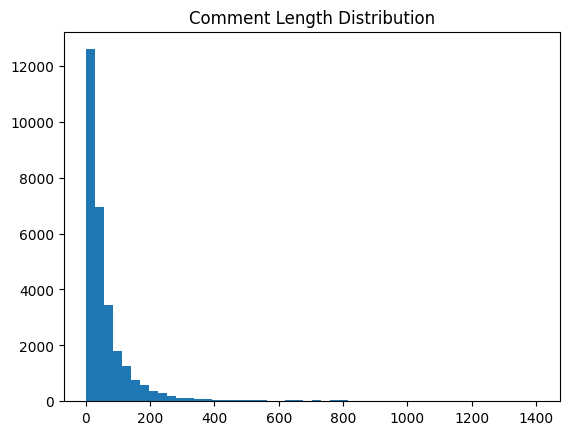

In [ ]:
#EDA
label_counts = train_df[LABEL_COLS].sum()
print(label_counts)

train_df['comment_len'] = train_df['comment_text'].apply(lambda x: len(str(x).split()))

plt.hist(train_df['comment_len'], bins=50)
plt.title("Comment Length Distribution")
plt.show()

In [ ]:
#PREPROCESSING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_comment'] = train_df['comment_text'].apply(clean_text)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_comment'])

seq = tokenizer.texts_to_sequences(train_df['clean_comment'])
X = pad_sequences(seq, maxlen=MAX_LEN)

Y = train_df[LABEL_COLS].values.astype('float32')

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.15, random_state=42)

In [ ]:
#CALLBACKS
def get_callbacks(name):
    return [
        EarlyStopping(patience=3, restore_best_weights=True),
        ReduceLROnPlateau(patience=2),
        ModelCheckpoint(f"best_{name}.h5", save_best_only=True)
    ]

In [ ]:
#BiLSTM Model
inp = Input(shape=(MAX_LEN,))
x = layers.Embedding(MAX_VOCAB, EMBED_DIM)(inp)
x = layers.SpatialDropout1D(0.2)(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_LABELS, activation='sigmoid')(x)

bilstm = models.Model(inp, out)
bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bilstm.fit(X_train, y_train,
           validation_data=(X_val, y_val),
           epochs=EPOCHS,
           batch_size=BATCH_SIZE,
           callbacks=get_callbacks("bilstm"))

pred_bl = bilstm.predict(X_val)
roc_bl = roc_auc_score(y_val, pred_bl, average='macro')
print("BiLSTM ROC-AUC:", roc_bl)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4889 - loss: 0.2847

98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.5647 - loss: 0.1945 - val_accuracy: 0.9957 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 2/5
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6995 - loss: 0.1466

98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.7203 - loss: 0.1352 - val_accuracy: 0.9957 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 3/5
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8466 - loss: 0.0870

98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.8374 - loss: 0.0766 - val_accuracy: 0.9957 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 4/5
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8850 - loss: 0.0585

98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.8877 - loss: 0.0547 - val_accuracy: 0.9957 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9348 - loss: 0.0473

98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9298 - loss: 0.0449 - val_accuracy: 0.9957 - val_loss: 0.0589 - learning_rate: 0.0010
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
BiLSTM ROC-AUC: 0.9709839476321598


In [ ]:
#TextCNN Model
inp = Input(shape=(MAX_LEN,))
x = layers.Embedding(MAX_VOCAB, EMBED_DIM)(inp)

branches = []
for k in [2,3,4]:
    c = layers.Conv1D(128, k, activation='relu')(x)
    c = layers.GlobalMaxPooling1D()(c)
    branches.append(c)

x = layers.Concatenate()(branches)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_LABELS, activation='sigmoid')(x)

cnn = models.Model(inp, out)
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

cnn.fit(X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks("cnn"))

pred_cnn = cnn.predict(X_val)
roc_cnn = roc_auc_score(y_val, pred_cnn, average='macro')
print("TextCNN ROC-AUC:", roc_cnn)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5009 - loss: 0.2838

98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step - accuracy: 0.5867 - loss: 0.1854 - val_accuracy: 0.9957 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 2/5
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7277 - loss: 0.0959

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7682 - loss: 0.0780 - val_accuracy: 0.9957 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 3/5
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8668 - loss: 0.0551

98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8571 - loss: 0.0510 - val_accuracy: 0.9957 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8633 - loss: 0.0418 - val_accuracy: 0.9957 - val_loss: 0.0545 - learning_rate: 0.0010
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8447 - loss: 0.0353 - val_accuracy: 0.9957 - val_loss: 0.0632 - learning_rate: 0.0010
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
TextCNN ROC-AUC: 0.971040805925108


In [ ]:
#Hybrid Model
inp = Input(shape=(MAX_LEN,))
x = layers.Embedding(MAX_VOCAB, EMBED_DIM)(inp)

x = layers.Conv1D(128, 3, activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.GlobalMaxPooling1D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_LABELS, activation='sigmoid')(x)

hybrid = models.Model(inp, out)
hybrid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

hybrid.fit(X_train, y_train,
           validation_data=(X_val, y_val),
           epochs=EPOCHS,
           batch_size=BATCH_SIZE,
           callbacks=get_callbacks("hybrid"))

pred_h = hybrid.predict(X_val)
roc_h = roc_auc_score(y_val, pred_h, average='macro')
print("Hybrid ROC-AUC:", roc_h)

Epoch 1/5
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4947 - loss: 0.3084

98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5548 - loss: 0.1965 - val_accuracy: 0.9950 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 2/5
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6594 - loss: 0.0896

98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7302 - loss: 0.0733 - val_accuracy: 0.9957 - val_loss: 0.0555 - learning_rate: 0.0010
Epoch 3/5
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8598 - loss: 0.0521

98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8555 - loss: 0.0484 - val_accuracy: 0.9957 - val_loss: 0.0548 - learning_rate: 0.0010
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8699 - loss: 0.0403 - val_accuracy: 0.9957 - val_loss: 0.0557 - learning_rate: 0.0010
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8842 - loss: 0.0367 - val_accuracy: 0.9957 - val_loss: 0.0587 - learning_rate: 0.0010
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Hybrid ROC-AUC: 0.9711731676846499


In [ ]:
#Comparison
print("\nFinal Results:")
print("BiLSTM :", roc_bl)
print("TextCNN:", roc_cnn)
print("Hybrid :", roc_h)


Final Results:
BiLSTM : 0.9709839476321598
TextCNN: 0.971040805925108
Hybrid : 0.9711731676846499


In [ ]:
#Prediction Function
def predict(comment):
    text = clean_text(comment)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN)

    pred = hybrid.predict(pad)[0]

    print("\nComment:", comment)
    for l, p in zip(LABEL_COLS, pred):
        print(f"{l:15}: {p:.4f}")

In [ ]:
#Test
predict("You are amazing!")
predict("I will kill you idiot")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Comment: You are amazing!
toxic          : 0.1948
severe_toxic   : 0.0019
obscene        : 0.0148
threat         : 0.0030
insult         : 0.0162
identity_hate  : 0.0050
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Comment: I will kill you idiot
toxic          : 0.9868
severe_toxic   : 0.2812
obscene        : 0.8616
threat         : 0.0651
insult         : 0.8330
identity_hate  : 0.2057
